# RETO 2: CLASIFICACION DE FLORES

### Importar librerías

In [19]:
from urllib.request import urlretrieve
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, ConfusionMatrixDisplay, classification_report

### Traer y leer Dataset

In [20]:
irisURL = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(irisURL)
df_iris = pd.read_csv(irisURL, sep=',', names=["Largo_Sepalo", "Ancho_Sepalo", "Largo_Petalo", "Ancho_Petalo", "Clase"])
df_iris = df_iris.dropna()

In [21]:
print(df_iris)
print(df_iris.head())
print(df_iris.tail())

     Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo           Clase
0             5.1           3.5           1.4           0.2     Iris-setosa
1             4.9           3.0           1.4           0.2     Iris-setosa
2             4.7           3.2           1.3           0.2     Iris-setosa
3             4.6           3.1           1.5           0.2     Iris-setosa
4             5.0           3.6           1.4           0.2     Iris-setosa
..            ...           ...           ...           ...             ...
145           6.7           3.0           5.2           2.3  Iris-virginica
146           6.3           2.5           5.0           1.9  Iris-virginica
147           6.5           3.0           5.2           2.0  Iris-virginica
148           6.2           3.4           5.4           2.3  Iris-virginica
149           5.9           3.0           5.1           1.8  Iris-virginica

[150 rows x 5 columns]
   Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo       

## <span style="color:yellow">Bayes Ingenuos</span>

### Separar X, y, entrenamiento y pruebas

In [22]:
X_bayes = df_iris.drop('Clase', axis=1).copy()
y_bayes = df_iris['Clase'].copy()

In [23]:
X_train_bayes, X_test_bayes, y_train_bayes, y_test_bayes = train_test_split(X_bayes, y_bayes, test_size=0.3, random_state=42)

### Entrenar modelo logístico, predicciones

In [24]:
modelo_bayes = GaussianNB()
modelo_bayes.fit(X_train_bayes, y_train_bayes)

GaussianNB()

In [25]:
pred_bayes = modelo_bayes.predict(X_test_bayes)

print(pred_bayes)

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-setosa' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa']


### Validaciones

In [26]:
accuracy_bayes = accuracy_score(y_test_bayes, pred_bayes)
report = classification_report(y_test_bayes, pred_bayes)

print(f"Precision de Bayes Ingenuos: ", accuracy_bayes)
print(report)

Precision de Bayes Ingenuos:  0.9777777777777777
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45



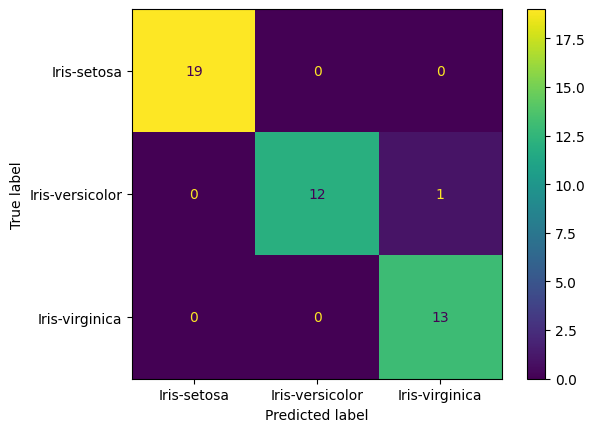

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test_bayes, pred_bayes)

### Cambiar hiperparametros

Mejor valor de var_smoothing: 0.02009233002565047 con precisión realista de: 0.9333333333333333
Precision en test:  1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



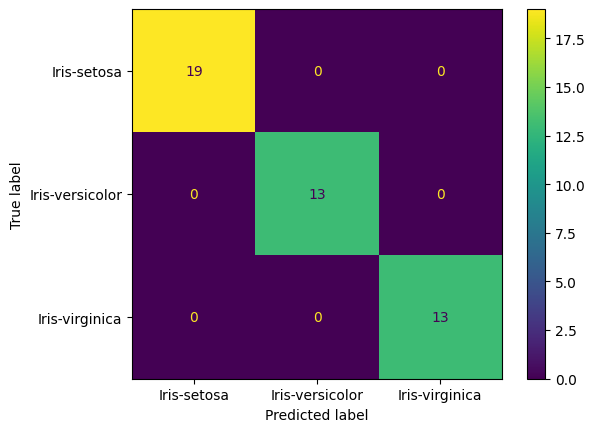

In [28]:
param_grid = {'var_smoothing': np.logspace(0, -12, num=100)}

grid = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='accuracy')

grid.fit(X_train_bayes, y_train_bayes)
        
print(f"Mejor valor de var_smoothing: {grid.best_params_['var_smoothing']} con precisión realista de: {grid.best_score_}")
pred_bayes_grid = grid.predict(X_test_bayes)
print("Precision en test: ", accuracy_score(y_test_bayes, pred_bayes_grid))
print(classification_report(y_test_bayes, pred_bayes_grid))
ConfusionMatrixDisplay.from_predictions(y_test_bayes, grid.predict(X_test_bayes))

## <span style="color:yellow">Maquinas de Soporte Vectorial</span>

### Separar X, y, entrenamiento y pruebas

In [29]:
X_svm = df_iris.drop('Clase', axis=1).copy()
y_svm = df_iris['Clase'].copy()

In [30]:
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(X_svm, y_svm, test_size=0.3)

### Entrenar modelo logístico, predicciones

In [31]:
modelo_svm = SVC()
modelo_svm.fit(X_svm_train, y_svm_train)

SVC()

In [32]:
pred_svm = modelo_svm.predict(X_svm_test)

print(pred_svm)

['Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica']


### Validaciones

In [33]:
accuracy_svm = accuracy_score(y_svm_test, pred_svm)
report = classification_report(y_svm_test, pred_svm)

print(f"Precision de SVM: ", accuracy_svm)
print(report)

Precision de SVM:  0.9555555555555556
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       0.94      0.94      0.94        17
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



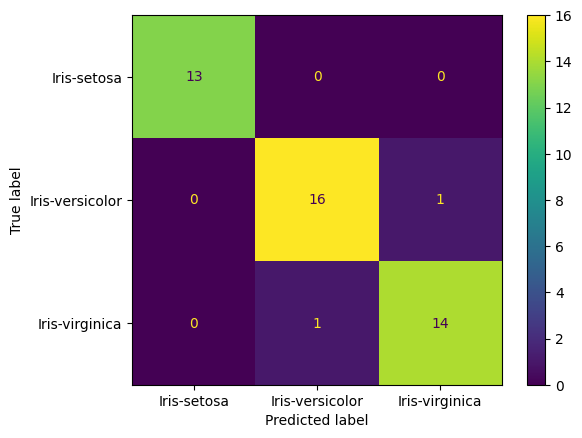

In [34]:
ConfusionMatrixDisplay.from_predictions(y_svm_test, pred_svm)

### Cambiar hiperparametros

Mejores hiperparámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'} con precisión realista de: 0.9904761904761905
Precision en test:  0.9333333333333333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       0.94      0.88      0.91        17
 Iris-virginica       0.88      0.93      0.90        15

       accuracy                           0.93        45
      macro avg       0.94      0.94      0.94        45
   weighted avg       0.93      0.93      0.93        45



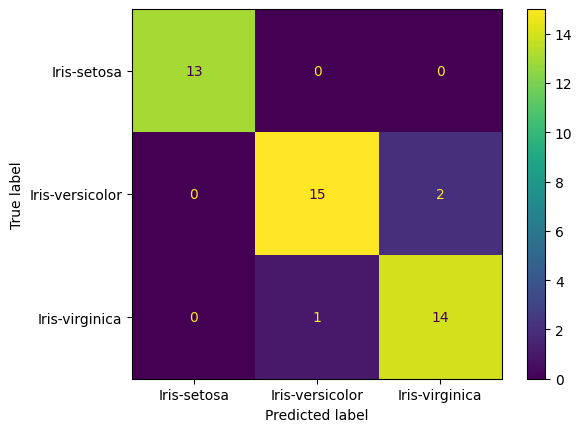

In [35]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear', 'poly'] 
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')

grid_svm.fit(X_svm_train, y_svm_train)

print(f"Mejores hiperparámetros: {grid_svm.best_params_} con precisión realista de: {grid_svm.best_score_}")

best_svm = grid_svm.best_estimator_
pred_svm_grid = best_svm.predict(X_svm_test)
print("Precision en test: ", accuracy_score(y_svm_test, pred_svm_grid))
print(classification_report(y_svm_test, pred_svm_grid))
ConfusionMatrixDisplay.from_predictions(y_svm_test, pred_svm_grid)

## <span style="color:red">Predecir</span>

In [ ]:
nueva_flor = np.array([[8, 3, 8, 0.2]])

prediccion_bayes = grid.predict(nueva_flor)
prediccion_svm = best_svm.predict(nueva_flor)

print(f"Predicción de Bayes Ingenuos para la nueva flor: {prediccion_bayes[0]}")
print(f"Predicción de SVM para la nueva flor: {prediccion_svm[0]}")

Predicción de Bayes Ingenuos para la nueva flor: Iris-setosa
Predicción de SVM para la nueva flor: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


## <span style="color:red">Conclusiones</span>

<p>De lo obsevado podemos observar lo siguiente:</p>

<ul>
    <li>
        El modelo <strong>Bayes Ingenuo</strong> en su forma predeterminada pudo casi alcanzar una precisión de 1.0, equivocandose en la predicción de unicamente un dato, exactamente, predijo mal un Versicolor afirmando que es un Virginica, por lo que podemos inferir que son Clases con características con valores más cercanos que la clase Setosa, como también se puede ver en el reporte de precision, recall y score.
    </li>
    <li>
        El hiperparametro a cambiar en <strong>Bayes Ingenuo</strong> es el "var_smoothing" que es un valor pequeño que se le suma a la varianza para evitar división por cero. Se utilizaron 100 numeros para entrenar varios modelos y encontrar el mejor valor para este hiperparametro, el cual fue 0.0200... Con este valor se obtiene una precisión promedio de aproximadamente 93%.
    </li>
    <li>
        El modelo <strong>Bayes Ingenuo</strong> presenta en su condición predeterminada una precisión casi del 98%, lo cual indica que este resultado está ligeramente optimista debido al split específico que tiene en los datos. Pues con el promediado que obtuvimos al utilizar GridSearchCV nos damos cuenta que una precisión más realista del modelo es aproximadamente 93%
    </li>
    <li>
        El modelo <strong>Máquinas de Soporte Vectorial</strong> en su forma básica obtuvo una precisión de ~95% incluso sin modificar ningun parámetro, indicando que el dataset es relativamente fácil de separar. En estas condiciones, el modelo predice mal dos flores como Virginica que deberían ser Versicolor, reforzando así lo que ya habiamos visto en el modelo anterior, que la clase Setosa es más separable respecto a las otras, que las demás entre si.
    </li>
    <li>
        Para el modelo <strong>Máquinas de Soporte Vectorial</strong> los hiperparámetros que se pueden modificar son: La regularización C que controla el margen de error, entre más pequeño más margen y entre más grande más perfeccionista es. El kernel es para definir la frontera, se puede elegir "lineal" para una frontera lineal, "rbf" para una frontera no lineal, y "poly" para una polinomial. Y gamma para definir que tan suave o compleja es la frontera.
    </li> 
    <li>
        Al modificar los hiperparámetros del modelo <strong>Máquinas de Soporte Vectorial</strong> obtenemos una precisión realista de ~98%, y para esto se debió usar C = 0.1, gamma = 0.1, y kernel = poly. Indicando que el dataset es casi linealmente separable pero si existe cierta superposición entre las clases Versicolor y Virginica, lo que se logra separar mejor con el kernel polinomial porque este permite una frontera ligeramente no lineal. El valor de C sugiere que el modelo generaliza mejor cuando no intenta ajustar perfectamente todo, es decir, cuando deja un margen más amplio; y el gamma es moderado evitando fronteras demasiado complejas o demasiado suaves.
    </li>
</ul>